# Time-Use Habits in Finland — Statistical Analysis

**Scenario.** A research organisation's Board commissioned a survey into how individuals and households in Finland spend their time, and wants a report answering four questions:

1. Who are the individuals in the sample?
2. How much time do households spend on average on each activity, per day?
3. Do living environment or day of week make a difference in time spent on any activity?
4. Which activities are associated with each other?

 This notebook is divided into 4 Steps:
 - Step 0: understanding the data
 - Step 1: cleaning it
 - Step 2: descriptive exploration and PCA

 TO BE IMPLEMENETED:
 - Step 3: confidence intervals for household-level activity means
 - Step 4: statistical testing of group differences and associations


> **AI-use declaration (placeholder — complete before submission).** This notebook was developed
> with the assistance of an AI tool (Claude). Per the assignment instructions, the final report must
> declare this on its cover page and describe every interaction in an appendix (tool name/version,
> purpose, links/records of the conversation, and how the output was used and checked). That
> declaration belongs in the final report document, not in this notebook — keep this note here only
> as a reminder while the notebook is still in progress.


---
## STEP 0 — Before touching the dataset

**Objective of this step.** Read `habits.txt` carefully and understand, *before* writing any
code: what each variable means and what values it can take, what a row represents (an individual? a
household? a household on a given day?), which variables encode *living environment* and *day of
week*, and whether the documentation actually matches what is in the file.


In [1]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=ec899cc2ab06b552a60fd6ab99251727b9dce933f7457e2eec2cf5089778cc47
  Stored in directory: /root/.cache/pip/wheels/87/6e/8f/914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor-analyzer


In [2]:
# Libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# Display settings
RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

DATA_PATH = "habits.data"
DOC_PATH = "habits.txt"

print("Setup complete.")


Setup complete.


### 0.1 Documentation from `habits.txt`

**Demographic variables** (one value per person, repeated across that person's diary days: sex, for example, is the same on both a person's working-day row and their weekend row).

| Variable | Meaning | Coded values |
|---|---|---|
| `kohde` | Household ID | integer |
| `jasen` | Member ID within household | integer |
| `pvknro` | Day of week (of that particular diary day) | 1 = working day, 2 = weekend |
| `sp` | Sex | 1 = male, 2 = female |
| `IKAL1` | Age group | documented as 1 = 10–14 … but the raw file does **not** actually follow this coding |
| `ASALUE` | Living environment | 1 = city, 2 = municipality, 3 = rural area |

**Activity variables**:

| Variable | Activity | Type |
|---|---|---|
| `A1` | Working | minutes |
| `A2` | Sleeping | minutes |
| `A3` | Reading | minutes |
| `A4` | Dining at a restaurant | minutes |
| `A5` | Visiting a library (past 12 months) | 1 = yes, 2 = no |

So `A1`–`A4` are **continuous time variables** and `A5` is **categorical (binary)**. Data type matters for EDA
and PCA. For example, Pearson/Spearman correlation only make sense for `A1`–`A4`, while `A5`
needs to be summarised as a proportion instead.


In [3]:
#  Load the raw data
df_raw = pd.read_csv(DATA_PATH, sep=";", dtype=str)

print("Shape:", df_raw.shape)
print()
print(df_raw.dtypes)
print()
df_raw.head(10)


Shape: (745, 11)

kohde     object
jasen     object
pvknro    object
sp        object
ASALUE    object
IKAL1     object
A1        object
A2        object
A3        object
A4        object
A5        object
dtype: object



,kohde,jasen,pvknro,sp,ASALUE,IKAL1,A1,A2,A3,A4,A5
0,50002,1,1,1,1.0,49,0,560,0,80,1.0
1,50002,1,2,1,1.0,49,380,450,10,0,1.0
2,50003,1,1,2,2.0,41,0,470,30,100,1.0
3,50003,1,2,2,2.0,41,0,550,0,0,1.0
4,50004,2,1,1,1.0,62,640,410,0,0,1.0
5,50004,2,2,1,1.0,62,0,550,72,108,1.0
6,50005,1,1,2,1.0,46,0,540,40,?,2.0
7,50005,1,2,2,1.0,46,0,550,52,108,2.0
8,50006,1,1,2,2.0,33,0,540,0,90,1.0
9,50006,1,2,2,2.0,33,0,530,62,0,1.0


###  0.2 What does a row represent? Checking the documentation against the actual file

The documentation calls `kohde` a *household* ID and `jasen` a *member* ID. Before deciding how to
aggregate anything, we need to check:


1. How many people live in each household? If a household has more than one person, we'll need to sum their activity times to get the household total, since that's what's being asked. If each household has only 1 person, no summing is needed.

2. How many diary-day rows does each person have (max 2: one working
   day, one weekend day)? This matters for Step 4: comparing working
   day vs. weekend for the same person only works if that person has
   both days recorded.

In [4]:
# Structural checks:
members_per_household = df_raw.groupby("kohde")["jasen"].nunique()
rows_per_person = df_raw.groupby(["kohde", "jasen"]).size()

print("Number of distinct households (kohde):", df_raw["kohde"].nunique())

print("\n Q1: How many people live in each household?")
print(members_per_household.value_counts()) # 378 households have 1 person

print("\n Q2: How many diary-day rows does each person have?" ) # how many diary days each person registered, max 2
print(rows_per_person.value_counts()) # 367 people completed both days

print("\n day type (working day vs. weekend) counts") # working day vs. weekend counts
print(df_raw["pvknro"].value_counts())

Number of distinct households (kohde): 378

 Q1: How many people live in each household?
jasen
1    378
Name: count, dtype: int64

 Q2: How many diary-day rows does each person have?
2    367
1     11
Name: count, dtype: int64

 day type (working day vs. weekend) counts
pvknro
1    377
2    368
Name: count, dtype: int64


**Finding.** Every household (`kohde`) in this file has exactly one sampled member
(`jasen` is unique within each household), and each person contributes two diary-day rows, one
per value of `pvknro` (working day / weekend), with 11 people missing one of their two days. So summarizing:

- a row is one person, on one specific day
- "household" and "individual" mean the same thing here, since every household has just 1 person
- `pvknro` describes the day, so the same person shows up once as a working day and once as a weekend

We still write the code to sum by household and day, instead of just assuming "1 row = 1 household". That way, if we ever use a bigger version of this survey with households of 2+ people, the code still works without changes.


---
## STEP 1 — Data preparation

**Objective of this step.** Turn the raw text file into a clean, correctly-typed table that can be
analysed: parse the inconsistently-formatted time variables, resolve the mismatch found in `IKAL1`,
quantify and treat missing values, check for implausible values, and give the categorical variables
readable labels. Every decision is justified.


### 1.1 Parsing the time variables (`A1`–`A4`)

A first look at the raw values already shows a problem: the same column mixes **plain numbers**
(e.g. `"380"`) with **`HH:MM`-formatted strings** (e.g. `"01:20"`). Both need to end up as the same
unit (minutes) before they can be compared or summed:

- a value containing `":"` is a duration written as hours:minutes → converted to `hours*60 + minutes`;
- a value without `":"` is already a plain minute count;
- the code `"?"` marks a missing observation and is converted to `NaN`.

We validate the parser by checking that the resulting minute values fall in a plausible daily range
(0–1440 minutes) for every activity, and that no single day's total across `A1`–`A4` exceeds 1440
minutes (24 hours). The survey doesn't require activities to add up to the full day, so getting less than 1440 minutes is totally normal. However, going over 1440 is physically impossible and would point straight to a data error.

In [5]:
# Parse A1-A4 from mixed "plain minutes" / "HH:MM" text into a single minutes unit
def parse_time_to_minutes(value):
    """Convert a raw A1-A4 entry to minutes.

    Handles three cases found in the raw file:
      - '?'              -> missing (NaN)
      - 'HH:MM'           -> H*60 + M
      - a plain number    -> already minutes
    """
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == "?":
        return np.nan
    if ":" in value:
        hours, minutes = value.split(":")
        return int(hours) * 60 + int(minutes)
    return float(value)


activity_raw_cols = {"A1": "working", "A2": "sleeping", "A3": "reading", "A4": "dining_restaurant"}

df = df_raw.copy()
for raw_col, nice_name in activity_raw_cols.items():
    df[f"{nice_name}_min"] = df[raw_col].apply(parse_time_to_minutes)

time_cols = [f"{name}_min" for name in activity_raw_cols.values()]

# Validation: plausible range + how many values came from each act.
for raw_col, nice_name in activity_raw_cols.items():
    col = f"{nice_name}_min"
    n_colon_format = df_raw[raw_col].astype(str).str.contains(":").sum()
    print(f"{nice_name:20s} range=[{df[col].min():.0f}, {df[col].max():.0f}] min   "
          f"n_missing={df[col].isna().sum():2d}   n_parsed_from_HH:MM={n_colon_format}")

daily_total = df[time_cols].sum(axis=1, skipna=True)
print()
print("Rows where A1+A2+A3+A4 exceeds 1440 minutes (should be none):", # careful if we had >1 person in the household
      int((daily_total > 1440).sum()))


working              range=[0, 1050] min   n_missing= 4   n_parsed_from_HH:MM=81
sleeping             range=[70, 900] min   n_missing= 8   n_parsed_from_HH:MM=80
reading              range=[0, 608] min   n_missing=12   n_parsed_from_HH:MM=82
dining_restaurant    range=[0, 240] min   n_missing= 9   n_parsed_from_HH:MM=82

Rows where A1+A2+A3+A4 exceeds 1440 minutes (should be none): 0


All four activities parse into a plausible 0-1440 minute range, and no single day's total exceeds 1440 minutes. Parsing looks correct, no impossible values introduced.

**Note**: In this case, each row = 1 person, 1 day, so the 0–1440 min check applies per person, not per household. A household with 2+ people could have a combined total above 1440.

### 1.2 `IKAL1` (age): documentation does not match the data

`habits.txt` documents `IKAL1` as a **9-level age-group code** (1 = 10–14 years … 9 = 75+). The raw
values in `habits.data`, however, look like **actual ages in years**, not group codes.


In [6]:
# IKAL1: confirm the documentation mismatch
df["IKAL1"] = df["IKAL1"].astype(int)
print("IKAL1 raw range:", df["IKAL1"].min(), "-", df["IKAL1"].max())


IKAL1 raw range: 20 - 84


We'll treat `IKAL1` as age in years (e.g. 49, 41, 62) and save it as `age_years`. From there we can
bin it into the standard age ranges from the documentation (10-14, 15-19, 20-24, ... 75+) as
`age_group`. The first two bands will end up empty, since no people in this sample is under 20.


In [7]:
# Build a readable age_group from the actual ages, using the documented band edges
age_bin_edges = [10, 15, 20, 25, 35, 45, 55, 65, 75, np.inf]
age_bin_labels = ["10-14", "15-19", "20-24", "25-34", "35-44",
                   "45-54", "55-64", "65-74", "75+"]

df["age_years"] = df["IKAL1"]
df["age_group"] = pd.cut(df["age_years"], bins=age_bin_edges, labels=age_bin_labels,
                          right=False, ordered=True)

print(df["age_group"].value_counts().sort_index())


age_group
10-14      0
15-19      0
20-24     24
25-34    113
35-44    124
45-54    162
55-64    183
65-74     86
75+       53
Name: count, dtype: int64


### 1.3 Recoding the remaining categorical variables

`pvknro`, `sp` and `ASALUE` are already coded exactly as documented, so we only need to write
readable labels.


In [8]:
# Recode pvknro, sp, ASALUE into readable categorical labels
df["pvknro"] = df["pvknro"].astype(int)
df["sp"] = df["sp"].astype(int)
df["ASALUE"] = df["ASALUE"].astype(float)


# int dtype can't hold NaN, so no .dropna() needed here
print("ASALUE missing:", df["ASALUE"].isna().sum(),
      f"({df['ASALUE'].isna().mean():.2%})")

# Data in the file looks coherent we can use asser directly to see if a condition is true
assert set(df["pvknro"].unique()) <= {1, 2}, "Unexpected pvknro code found"
assert set(df["sp"].unique()) <= {1, 2}, "Unexpected sp code found"
assert set(df["ASALUE"].dropna().unique()) <= {1.0, 2.0, 3.0}, "Unexpected ASALUE code found"

day_type_map = {1: "Working day", 2: "Weekend"}
sex_map = {1: "Male", 2: "Female"}
environment_map = {1.0: "City", 2.0: "Municipality", 3.0: "Rural area"}

df["day_type"] = df["pvknro"].map(day_type_map).astype("category")
df["sex"] = df["sp"].map(sex_map).astype("category")
df["living_environment"] = df["ASALUE"].map(environment_map).astype("category")

#Lets visualize new labels vs old

df[["pvknro", "day_type", "sp", "sex", "ASALUE", "living_environment"]].drop_duplicates().sort_values(
    ["pvknro", "sp", "ASALUE"]
)


ASALUE missing: 0 (0.00%)


,pvknro,day_type,sp,sex,ASALUE,living_environment
0,1,Working day,1,Male,1.0,City
13,1,Working day,1,Male,2.0,Municipality
37,1,Working day,1,Male,3.0,Rural area
6,1,Working day,2,Female,1.0,City
2,1,Working day,2,Female,2.0,Municipality
21,1,Working day,2,Female,3.0,Rural area
1,2,Weekend,1,Male,1.0,City
14,2,Weekend,1,Male,2.0,Municipality
38,2,Weekend,1,Male,3.0,Rural area
7,2,Weekend,2,Female,1.0,City


### 1.4 `A5` (library visits): another data-quality problem

`A5` is documented as strictly binary (1 = yes, 2 = no). Checking the raw values shows several that do
not fit that scheme.


In [9]:
# A5: check which raw values do not match the documented 1/2 coding

a5_raw_values = df_raw["A5"].value_counts(dropna=False)
print(a5_raw_values)
print()
a5_non_conforming = df_raw.loc[~df_raw["A5"].isin(["1.0", "2.0"]) & (df_raw["A5"] != "?")]
print(f"Rows with an A5 value that is neither 1.0, 2.0 nor '?': {len(a5_non_conforming)}")
a5_non_conforming[["kohde", "A5"]]


A5
1.0      474
2.0      209
?         42
0.0       17
120.0      1
60.0       1
420.0      1
Name: count, dtype: int64

Rows with an A5 value that is neither 1.0, 2.0 nor '?': 20


,kohde,A5
70,50162,0.0
71,50162,0.0
124,50319,0.0
125,50319,0.0
190,50530,0.0
191,50530,0.0
196,50550,0.0
197,50550,0.0
272,50766,120.0
273,50766,60.0


Beyond the `?` missing markers, `A5` contains a handful of undocumented values: `0.0` in 17 rows,
and minute-like entries (`60.0`, `120.0`, `420.0`) in 3 more. Rather than guess what these mean, we
stick to the documentation: only `1.0` ("yes") and `2.0` ("no") get recoded, everything else becomes
missing. That drops about 8% of the A5 data (42 + 17 + 3 out of 745 rows), a real cost, but safer
than making up an interpretation for values the documentation doesn't define.


In [10]:
# A5: Everything else becomes NaN
library_map = {"1.0": "Yes", "2.0": "No"}
# .map() automatically turns any value not in the dictionary into NaN
df["library_visit"] = df_raw["A5"].map(library_map).astype("category")

print(df["library_visit"].value_counts(dropna=False)) # also counts NaN
print(f"Share of A5 treated as missing: {df['library_visit'].isna().mean():.2%}")


library_visit
Yes    474
No     209
NaN     62
Name: count, dtype: int64
Share of A5 treated as missing: 8.32%


In [11]:
# Assemble the cleaned table and rename columns in English

id_cols = ["kohde", "jasen"]
demo_cols = ["day_type", "sex", "age_years", "age_group", "living_environment"]
activity_cols = time_cols + ["library_visit"]

df_clean = df[id_cols + demo_cols + activity_cols].copy()
df_clean = df_clean.rename(columns={
    "kohde": "household_id",
    "jasen": "member_id",
    "working_min": "working",
    "sleeping_min": "sleeping",
    "reading_min": "reading",
    "dining_restaurant_min": "dining_restaurant",
})
time_cols_clean = ["working", "sleeping", "reading", "dining_restaurant"]

print(df_clean.shape)
df_clean.info()
df_clean.head()


(745, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   household_id        745 non-null    object  
 1   member_id           745 non-null    object  
 2   day_type            745 non-null    category
 3   sex                 745 non-null    category
 4   age_years           745 non-null    int64   
 5   age_group           745 non-null    category
 6   living_environment  745 non-null    category
 7   working             741 non-null    float64 
 8   sleeping            737 non-null    float64 
 9   reading             733 non-null    float64 
 10  dining_restaurant   736 non-null    float64 
 11  library_visit       683 non-null    category
dtypes: category(5), float64(4), int64(1), object(2)
memory usage: 45.4+ KB


,household_id,member_id,day_type,sex,age_years,age_group,living_environment,working,sleeping,reading,dining_restaurant,library_visit
0,50002,1,Working day,Male,49,45-54,City,0.0,560.0,0.0,80.0,Yes
1,50002,1,Weekend,Male,49,45-54,City,380.0,450.0,10.0,0.0,Yes
2,50003,1,Working day,Female,41,35-44,Municipality,0.0,470.0,30.0,100.0,Yes
3,50003,1,Weekend,Female,41,35-44,Municipality,0.0,550.0,0.0,0.0,Yes
4,50004,2,Working day,Male,62,55-64,City,640.0,410.0,0.0,0.0,Yes


### 1.5 Missing values
With our data fully prepped, we measure the exact amount of missingness for each column.

In [12]:
# Missing value summary
na_summary = pd.DataFrame({
    "n_missing": df_clean.isna().sum(),
    "%_missing": (df_clean.isna().mean() * 100).round(2),
})
na_summary


,n_missing,%_missing
household_id,0,0.00
member_id,0,0.00
day_type,0,0.00
sex,0,0.00
age_years,0,0.00
age_group,0,0.00
living_environment,0,0.00
working,4,0.54
sleeping,8,1.07
reading,12,1.61


### 1.6 Decision-making on missing value

- `working`, `sleeping`, `reading` and `dining_restaurant`: each is missing in at most ~1.6% of rows on its own, and only 4.4% of rows are missing at least one of the four when checked together. This missingness is small, so dropping rows is fine for the multi-variable analyses (correlation, PCA) that need all four at once. For anything single-activity, we keep all the valid data we have instead of throwing away a whole row over one missing value elsewhere.

- `library_visit`: missing in ~8.3% of rows due to the invalid codes found earlier. Since we only need a simple yes/no proportion, we just drop these invalid rows for this specific calculation without affecting the rest of the dataset.

- No demographic variable (`day_type`, `sex`, `age_group`, `living_environment`) has any missing
  values, so no treatment is needed there.


In [13]:
any_missing_activity = df_clean[time_cols_clean].isna().any(axis=1)
print(f"Rows with at least one missing value among the 4 time activities: "
      f"{any_missing_activity.sum()} ({any_missing_activity.mean():.1%})")


Rows with at least one missing value among the 4 time activities: 33 (4.4%)


### 1.7 Outliers and inconsistencies

We already checked that no daily activities add up to more than 1,440 minutes. Now we just make sure the remaining values make sense: every time value must fall between 0 and 1,440 minutes, the ages must be realistic for adults, and all categorical codes must match what's documented.

In [14]:

for col in time_cols_clean:
    out_of_range = ~df_clean[col].between(0, 1440) & df_clean[col].notna()
    print(f"{col:20s} out-of-[0,1440]-minute values: {int(out_of_range.sum()):2d}   "
          f"highest value seen: {df_clean[col].max():.0f} min")

age_out_of_range = ~df_clean["age_years"].between(15, 100)
print(f"\nAges outside a plausible [15, 100] range: {int(age_out_of_range.sum())}")
print(f"Actual age range in the sample: {df_clean['age_years'].min()}-{df_clean['age_years'].max()}")


working              out-of-[0,1440]-minute values:  0   highest value seen: 1050 min
sleeping             out-of-[0,1440]-minute values:  0   highest value seen: 900 min
reading              out-of-[0,1440]-minute values:  0   highest value seen: 608 min
dining_restaurant    out-of-[0,1440]-minute values:  0   highest value seen: 240 min

Ages outside a plausible [15, 100] range: 0
Actual age range in the sample: 20-84


No value falls outside the 0-1440 minute range, and ages are all realistic for adults. The highest
single values, working 1050 minutes (17.5 hours), sleeping 900 minutes (15 hours), reading 608
minutes (10 hours), are extreme, but they are physically possible for a single day (like a very long shift or a day off). Therefore, we keep them instead of deleting or imputing them, because they represent real human behavior rather than data entry errors.

We didn't use a statistical rule like IQR or z-scores here, because these distributions have a lot
of genuine zeros (someone who simply didn't work, read, or eat out that day). A statistical outlier
test would flag those zeros as extreme, even though they're the most common, valid answer for that
activity. A physical range check, can this many minutes fit in a day, is the more meaningful test
for this kind of activity-time data.

Together with the checks in Section 1.3, this confirms there are no other major errors besides the
two we already fixed: the mixed time formats in A1-A4 and the undocumented codes in A5.


### 1.8 Household-level aggregation

As each household has only one member (e.g., a person reading for 60 minutes equals a household total of 60 minutes), individual and household activities are identical. We still group and sum by household and day to keep the code flexible for any household size and prepare the table for Step 3.

In [15]:
# Household-day level aggregation (sum across household members)
df_household_day = (
    df_clean
    .groupby(["household_id", "day_type"], observed=True)[time_cols_clean]
    .sum(min_count=1)
    .reset_index()
)

print(df_household_day.shape)
df_household_day.head()


(745, 6)


,household_id,day_type,working,sleeping,reading,dining_restaurant
0,50002,Weekend,380.0,450.0,10.0,0.0
1,50002,Working day,0.0,560.0,0.0,80.0
2,50003,Weekend,0.0,550.0,0.0,0.0
3,50003,Working day,0.0,470.0,30.0,100.0
4,50004,Weekend,0.0,550.0,72.0,108.0


In [16]:
# Final cleaned tables produced
print("df_clean       (data per person):", df_clean.shape)
print("df_household_day (activity times per household):", df_household_day.shape)


df_clean       (data per person): (745, 12)
df_household_day (activity times per household): (745, 6)


### Step 1 recap

Data preparation is done. Starting from 745 raw rows with mixed time formats, an undocumented age
coding, and a handful of miscoded A5 values, we now have two clean tables:

- `df_clean`: 745 rows, one per person per diary day, with typed demographics and activity times
  in minutes
- `df_household_day`: the same activity times summed to the household-day level, ready for Step 3

Missingness is low (under 2% per activity, 8.3% for library visits) and no impossible values
remain. Step 2 uses `df_clean` to answer question 1 (who's in the sample) and start on question 4
(which activities are associated with each other).


---
## STEP 2 — Descriptive exploration and PCA

**Objective of this step.** Characterise who is in the sample (question 1) and see how people spend their time across different activities. Then, we'll use a correlation matrix and a PCA to preview how activities relate to one another (Question 4), providing an overview before moving on to the statistical analysis in the following steps.

### 2.1 Characterisation of the individuals in the sample

We summarise the demographic variables of the sample with frequency/proportion tables and bar
plots. Because each person contributes two rows (one per diary day), we compute these on the
**per-person** demographics (`sex`, `age_group`, `living_environment`, these do not vary within a
person) rather than double-counting each person once per day.

Note: `day_type` is a property of the *row* (working day vs. weekend), not of the *person*, so we only plot what characterises the person.


In [17]:

person_demo = df_clean.drop_duplicates(subset=["household_id", "member_id"])[["sex", "age_group", "living_environment"]]

for col in ["sex", "age_group", "living_environment"]:
    freq = person_demo[col].value_counts().sort_index()
    prop = (person_demo[col].value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"--- {col} ---")
    print(pd.DataFrame({"n": freq, "%": prop}))
    print()

print(f"Total individuals characterised: {person_demo.shape[0]}")


--- sex ---
          n     %
sex              
Female  196  51.9
Male    182  48.1

--- age_group ---
            n     %
age_group          
10-14       0   0.0
15-19       0   0.0
20-24      12   3.2
25-34      57  15.1
35-44      64  16.9
45-54      81  21.4
55-64      93  24.6
65-74      44  11.6
75+        27   7.1

--- living_environment ---
                      n     %
living_environment           
City                240  63.5
Municipality         58  15.3
Rural area           80  21.2

Total individuals characterised: 378


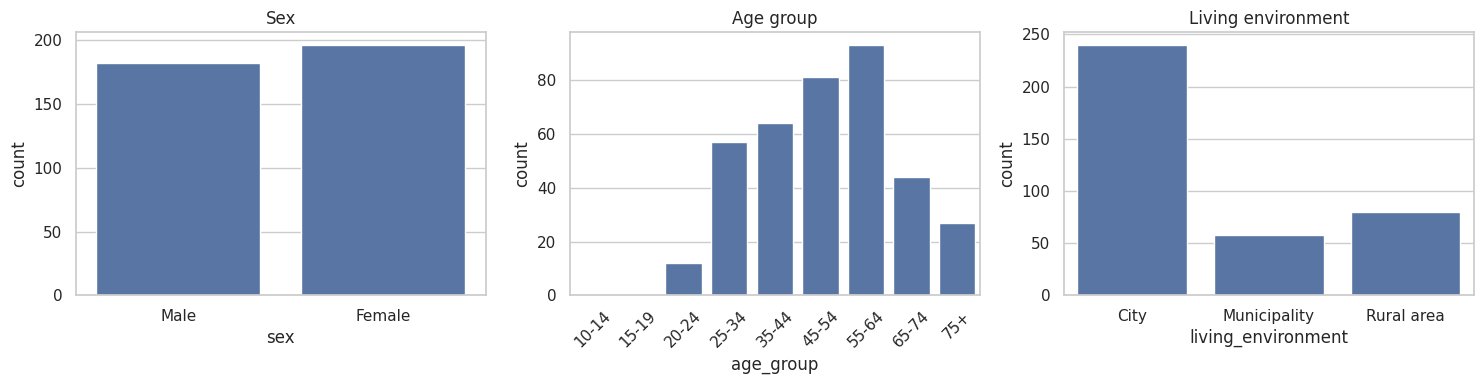

In [18]:
# Demographic bar plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="sex", data=person_demo, ax=axes[0], order=["Male", "Female"])
axes[0].set_title("Sex")

sns.countplot(x="age_group", data=person_demo, ax=axes[1],
              order=[c for c in person_demo["age_group"].cat.categories])
axes[1].set_title("Age group")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(x="living_environment", data=person_demo, ax=axes[2],
              order=["City", "Municipality", "Rural area"])
axes[2].set_title("Living environment")

plt.tight_layout()
plt.show()


The sample is close to balanced by sex, spans working-age adults with a broad spread across age
groups, and is dominated by people living in cities, with municipalities and rural areas each
making up a smaller share.

### 2.2 Descriptive statistics of time spent per activity

For the four continuous activities we report the mean, median and standard deviation (in minutes and,
for readability, in hours), then visualise each variable's distribution.


In [19]:
#  Descriptive statistics table (minutes and hours)
desc_minutes = df_clean[time_cols_clean].describe().T[["mean", "50%", "std", "min", "max"]]
desc_minutes.columns = ["mean_min", "median_min", "sd_min", "min_min", "max_min"]
desc_minutes["mean_hours"] = (desc_minutes["mean_min"] / 60).round(2)
desc_minutes["median_hours"] = (desc_minutes["median_min"] / 60).round(2)
desc_minutes.round(1)


,mean_min,median_min,sd_min,min_min,max_min,mean_hours,median_hours
working,122.1,0.0,209.0,0.0,1050.0,2.0,0.0
sleeping,518.5,510.0,100.3,70.0,900.0,8.6,8.5
reading,48.0,30.0,68.1,0.0,608.0,0.8,0.5
dining_restaurant,48.6,0.0,58.7,0.0,240.0,0.8,0.0


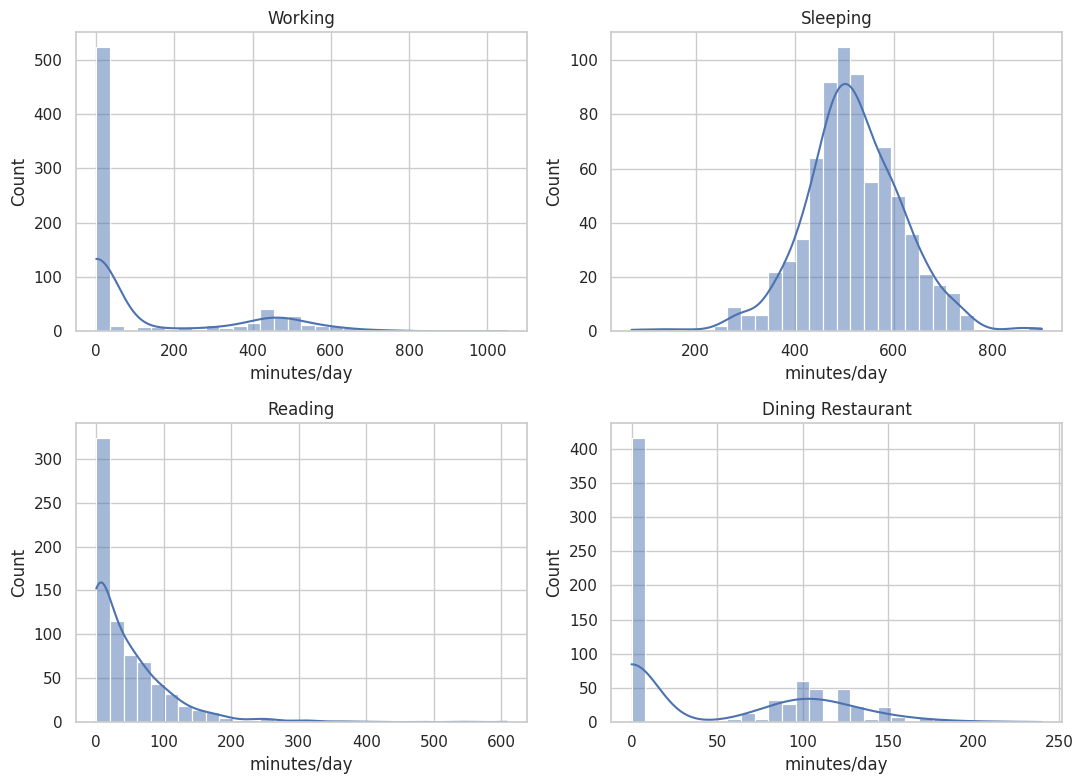

In [20]:
#  Histograms (num. feat) of each activity (distribution shape)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), time_cols_clean):
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("minutes/day")
plt.tight_layout()
plt.show()


`working` and `dining_restaurant` are heavily right-skewed with a large mass at 0: many days have
no work or no restaurant visit at all. That fits people not working on weekends, and eating out
simply being infrequent. `sleeping` looks roughly symmetric, centred a little above 7-8 hours.
`reading` is also right-skewed with a spike at 0. This skew is why we'll prefer Spearman over
Pearson for the correlation matrix below, since Pearson assumes a roughly linear, symmetric
relationship.


#### A first look: does time spent vary by group?

Question 3 asks whether living environment or day of week make a difference. We're not testing
that formally yet, that's Step 4, but the two boxplots below give a quick preview of what to
expect.


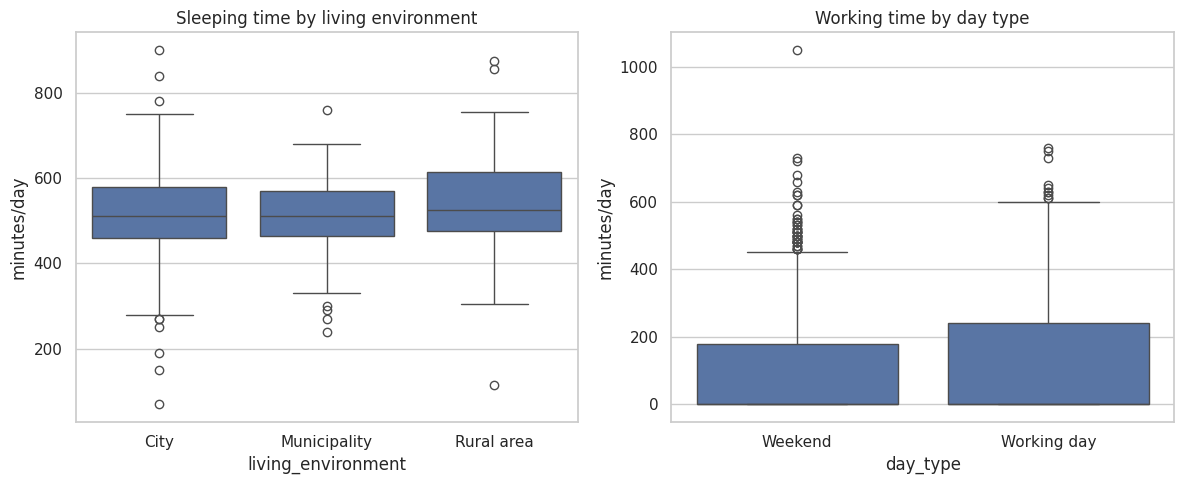

In [21]:
# We are interested in whether time spent differs by living environment
# or by day type -> box plot vis. + statis later
# Boxplots by group: living environment and day type

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="living_environment", y="sleeping", data=df_clean, ax=axes[0],
            order=["City", "Municipality", "Rural area"])
axes[0].set_title("Sleeping time by living environment")
axes[0].set_ylabel("minutes/day")

sns.boxplot(x="day_type", y="working", data=df_clean, ax=axes[1])
axes[1].set_title("Working time by day type")
axes[1].set_ylabel("minutes/day")

plt.tight_layout()
plt.show()


Sleeping time stays fairly stable across living environments, centred around 8-9 hours, with only
a few low and high outliers. Working time tells a clearer story: it's mostly zero on weekends,
since most people don't work then, and concentrated on working days instead, with a few long
outliers on both sides. These patterns line up with what we'd expect, and Step 4 will test whether
they're statistically significant.


### 2.3 `A5` — library visits (descriptive)

Since `library_visit` is categorical (yes/no), it is summarised as a proportion.


                 n
library_visit     
Yes            474
No             209
NaN             62

Proportion among non-missing responses (%):
library_visit
Yes    69.4
No     30.6
Name: proportion, dtype: float64


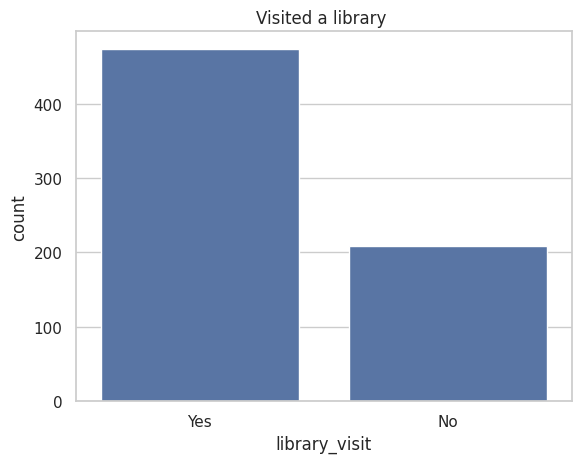

In [22]:
# Library visits: proportion table + bar plot
lib_summary = df_clean["library_visit"].value_counts(dropna=False)
lib_prop = (df_clean["library_visit"].value_counts(normalize=True, dropna=True) * 100).round(1)
print(pd.DataFrame({"n": lib_summary}))
print()
print("Proportion among non-missing responses (%):")
print(lib_prop)

sns.countplot(x="library_visit", data=df_clean, order=["Yes", "No"], color="#4C72B0")
plt.title("Visited a library ")
plt.show()


About 69% of people with a valid answer say they visited a library in the past year. Whether this
differs by living environment or age is, again, a question for Step 4, not something a simple
proportion can settle on its own.


### 2.4 Correlation matrix between activities

**Objective.** Provide a first, direct answer to question 4 ("which activities are associated with
each other") and motivate the PCA below.

**Method choice.** The histograms in Section 2.2 showed clear right-skew (with spikes at zero) for
`working`, `reading` and, to a lesser extent, `dining_restaurant`. Pearson correlation assumes a roughly linear relationship and is sensitive to this kind of skew and to outliers; Spearman's rank correlation is more appropriate here because, by ranking the continuous numeric values of minutes spent (from lowest to highest amount of time), it only requires a monotonic relationship and remains robust to skewed distributions. We still report skewness explicitly to justify this, and compute Pearson alongside it for comparison.


In [31]:
# MENCIONAR PERSON X CURIOSIDAD LO CALAULMOS PERO EL CORRECTO ES Pearson -> CHECK CODE Y CELLS ABOVE
# Skewness check, then Spearman (primary) and Pearson (for comparison) correlations
corr_data = df_clean[time_cols_clean].dropna()
print(f"Complete cases used for the correlation matrix: {len(corr_data)} of {len(df_clean)} rows")
print()
print("Skewness per activity:")
print(corr_data.skew().round(2))

spearman_corr = corr_data.corr(method="spearman")
pearson_corr = corr_data.corr(method="pearson")

print("\nSpearman correlation matrix:")
print(spearman_corr.round(2))

print("\Pearson correlation matrix:")
print(pearson_corr.round(2))


Complete cases used for the correlation matrix: 712 of 745 rows

Skewness per activity:
working              1.37
sleeping            -0.10
reading              2.92
dining_restaurant    0.63
dtype: float64

Spearman correlation matrix:
                   working  sleeping  reading  dining_restaurant
working               1.00     -0.40    -0.19              -0.02
sleeping             -0.40      1.00     0.01               0.03
reading              -0.19      0.01     1.00              -0.06
dining_restaurant    -0.02      0.03    -0.06               1.00
\Pearson correlation matrix:
                   working  sleeping  reading  dining_restaurant
working               1.00     -0.39    -0.19              -0.02
sleeping             -0.39      1.00    -0.05               0.04
reading              -0.19     -0.05     1.00              -0.04
dining_restaurant    -0.02      0.04    -0.04               1.00


<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_601/1158881623.py:14: SyntaxWarning: invalid escape sequence '\P'
  print("\Pearson correlation matrix:")


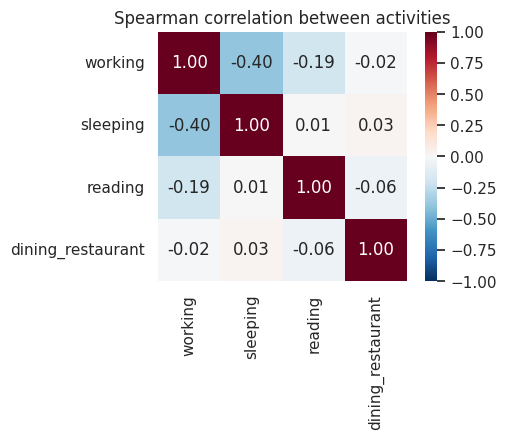

In [24]:
#  Correlation heatmap (Spearman)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Spearman correlation between activities")
plt.tight_layout()
plt.show()


**Interpretation.** The clearest relationship is between `working` and `sleeping`: a moderate
negative correlation (-0.40), meaning days with more work tend to
have less sleep, as one would expect.

Overall, these
four activities are only weakly correlated with each other, which already hints that a PCA on them
will not find a strongly dominant, easily-summarised component.


### 2.5 Principal Component Analysis

**Objective.** Formally check whether the four continuous activity-time variables share an underlying
correlation structure that can be summarised in fewer dimensions.

**Standardisation.** `working`, `sleeping`, `reading` and `dining_restaurant` are all measured in the
same unit (minutes), but their variances differ a lot: sleeping barely changes day to day compared
with working or dining out. PCA looks for directions of maximum variance, so a variable with a
bigger variance purely because of its scale would dominate the components. Standardising each
variable to mean 0 and variance 1 removes that scale effect and lets every variable contribute
equally.


Before looking at the components, we check if the data actually works well for PCA using two tests:
* **Bartlett’s test**: Confirms that our variables are correlated with each other rather than completely independent.
* **KMO measure**: Checks if the variables share enough common information to make a summary worthwhile.

In [25]:
#  Prepare data for PCA
pca_data = df_clean[time_cols_clean].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
print(f"Observations used for PCA: {pca_data.shape[0]} (complete cases on the 4 activities)")


Observations used for PCA: 712 (complete cases on the 4 activities)


In [26]:
#  Check PCA: Bartlett's test and KMO
chi_square_value, p_value = calculate_bartlett_sphericity(pca_data)
kmo_per_variable, kmo_overall = calculate_kmo(pca_data)

print(f"Bartlett's test of sphericity: chi2 = {chi_square_value:.2f}, p-value = {p_value:.4g}")
print(f"Overall KMO measure of sampling adequacy: {kmo_overall:.3f}")


Bartlett's test of sphericity: chi2 = 160.24, p-value = 5.265e-32
Overall KMO measure of sampling adequacy: 0.447


### Interpretation of Bartlett's Test and KMO

The Bartlett test gives a chi-square of 160.24 with a p-value of about 5e-32, far below 0.05. So we
reject the idea that the correlation matrix is just an identity matrix (i.e. that the four
variables are uncorrelated), which confirms they do share some real structure, like the
working-sleeping link seen earlier.

The KMO value, however, is only 0.447, below the usual 0.6 cutoff for "acceptable". With just four
variables and mostly weak pairwise correlations, there isn't much shared variance for PCA to
summarise. We go ahead with the PCA anyway, since it's part of what this project asks for, but we
treat this low KMO as an honest caveat: a two-component summary will only capture part of the
picture, not the whole story.


In [27]:
#  Fit PCA on all 4 standardised components, inspect eigenvalues / explained variance
pca = PCA(n_components=len(time_cols_clean), random_state=RANDOM_STATE)
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

pca_summary = pd.DataFrame({
    "eigenvalue": eigenvalues.round(3),
    "explained_variance_%": (explained_ratio * 100).round(1),
    "cumulative_%": (cum_explained * 100).round(1),
}, index=[f"PC{i+1}" for i in range(len(time_cols_clean))])
pca_summary


,eigenvalue,explained_variance_%,cumulative_%
PC1,1.420,35.4,35.4
PC2,1.082,27.0,62.5
PC3,0.960,24.0,86.4
PC4,0.544,13.6,100.0


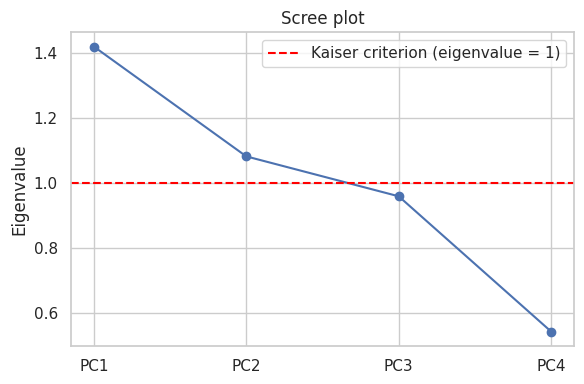

In [28]:
#  Scree plot
plt.figure(figsize=(6, 4))
components = np.arange(1, len(eigenvalues) + 1)
plt.plot(components, eigenvalues, marker="o")
plt.axhline(1, color="red", linestyle="--", label="Kaiser criterion (eigenvalue = 1)")
plt.xticks(components, [f"PC{i}" for i in components])
plt.ylabel("Eigenvalue")
plt.title("Scree plot")
plt.legend()
plt.tight_layout()
plt.show()


**Number of components to retain.** Based on the Kaiser criterion (eigenvalue > 1) and the scree plot, we retain **PC1 and PC2**. Together, they explain about 62% of the total variance. While typical for a small set of four variables, this two-dimensional summary provides a reasonable structure of the data.

In [29]:
#  Loadings for the retained components
n_components_retained = 2
loadings = pd.DataFrame(
    pca.components_[:n_components_retained].T,
    index=time_cols_clean,
    columns=[f"PC{i+1}" for i in range(n_components_retained)],
)
loadings.round(3)


,PC1,PC2
working,0.718,-0.102
sleeping,-0.649,-0.318
reading,-0.237,0.758
dining_restaurant,-0.084,-0.561


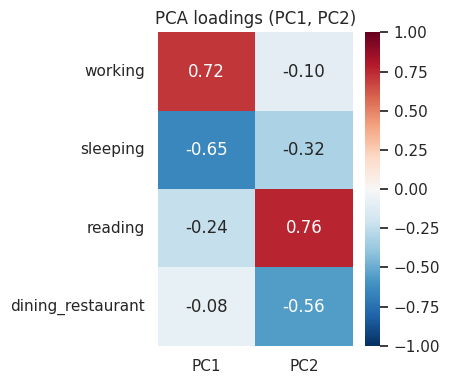

In [30]:
# Loadings heatmap
plt.figure(figsize=(4.5, 4))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("PCA loadings (PC1, PC2)")
plt.tight_layout()
plt.show()


### Interpretation of the components

PC1 works like a "work versus rest" axis: it contrasts `working` (+0.72) with `sleeping` (-0.65),
so a high score means someone who works more and sleeps less, the main trade-off in this data. PC2
works more like a leisure axis: it contrasts `reading` (+0.76) with `dining_restaurant` (-0.56) and
`sleeping` (-0.32), separating people who spend their spare time reading at home from those who
spend it eating out.

So the work-rest trade-off is clearly the strongest pattern, and the second component picks up a
secondary split between different kinds of leisure time.


---
## Step 2 recap, and what's still open

Here's where the four questions from the brief stand after Steps 0-2:

1. **Who is in the sample?** Answered in 2.1: 378 people, close to balanced by sex, mostly
   working-age adults, and mostly living in cities.
2. **Average time per activity, per household?** Not yet. `df_household_day` is ready for the
   confidence intervals this needs in Step 3.
3. **Differences by living environment or day of week?** Only previewed visually so far (2.2).
   Needs formal testing in Step 4, across all four activities and both grouping variables.
4. **Which activities are associated with each other?** Partly answered: the correlation matrix
   (2.4) found a moderate work-sleep trade-off and otherwise weak links, and the PCA (2.5)
   summarised that into two components explaining about 62% of the variance. Step 4 would confirm
   whether these relationships are statistically significant, not just descriptively present.

`df_clean` and `df_household_day` are both ready to be reused as they are for Steps 3 and 4.
